In [1]:
import torch
!pip install torch-geometric -q
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch.__version__}.html -q
!pip install scikit-learn==1.4.2 imbalanced-learn==0.11.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 100.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 117.8 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 15.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [2]:
!git clone https://github.com/Kyanh56709/Diff-GVAE

Cloning into 'Diff-GVAE'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 147 (delta 79), reused 103 (delta 42), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 31.16 MiB | 32.39 MiB/s, done.
Resolving deltas: 100% (79/79), done.


In [3]:
###### import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import sys
sys.path.append('/kaggle/working/Diff-GVAE/')

data = torch.load('/kaggle/input/dyam123/data_247_scaled_ln_pc_ihc_g.pt', weights_only = False)
DIM_CLINICAL = data['patient'].x_clinical.shape[1]
DIM_PATHOLOGY = data['patient'].x_pathology.shape[1] # Dimension of GLCM features
DIM_RADIOLOGY = data['lesion'].x.shape[1] 
print(f"Clinical Dim: {DIM_CLINICAL}, Path Dim: {DIM_PATHOLOGY}, Rad Dim: {DIM_RADIOLOGY}")

train_config = {
    'data_path': '/kaggle/input/dyam123/data_247_scaled_ln_pc_ihc_g.pt',
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'n_splits': 10,
    'epochs': 2000, 
    'patience': 30,
    'patience_early_stopping': 30,
    'lr': 0.001,
    'wd': 1e-4,
    'loss_weights': {
        'class': 1.0,
        'cross_cl': 0.2,
        'rec_attr': {'clinical': 2.0, 'pathology': 1.0, 'radiology': 1.0},
        'rec_struct': 0.1,
        'kl': 0.0000001,
    },
    'annealing': {
        'kl': {'start_weight': 0.0, 'end_weight': 0.0000001, 'start_epoch': 20, 'end_epoch': 300},
        'cross_cl': {'start_weight': 0.1, 'end_weight': 0.1, 'start_epoch': 20, 'end_epoch': 100},
    },
    'pca_config': {
        'clinical': 16,         # Reduce from 64 features
        'pathology': 8,         # Reduce 137 features   
    },
    'lesion_pca_config': {
        'n_components': 15, # <-- This must match lesion_feature_dim above
    },
    'cross_cl_temp': 0.1,
    'grad_clip_norm': 1.0,
    'print_every_k_epochs': 10,
}

model_config = {
    'view_configs': {
        'clinical': {'in_channels': DIM_CLINICAL, 'hidden_channels_vae': 256, 'heads': 8, 'dropout': 0.5, 'num_gnn_layers': 2, 'edge_dim': 1},
        'pathology': {'in_channels': DIM_PATHOLOGY, 'hidden_channels_vae': 128, 'heads':8, 'dropout': 0.5, 'num_gnn_layers': 2, 'edge_dim': 1},
        'radiology': {'in_channels': 32, 'hidden_channels_vae': 128, 'heads': 8, 'dropout': 0.5, 'num_gnn_layers': 2, 'edge_dim': 1},
        # 'genomics': {
        #     'in_channels': DIM_GENOMICS, # From your data structure (x_genomics shape is [366, 10])
        #     'hidden_channels_vae': 64, # Can be tuned, 128 is a good start
        #     'num_gnn_layers_vae': 2,
        #     'heads': 8,
        #     'dropout': 0.5,
        #     'edge_dim': -1 # Your similar_to_genomics has an edge_attr
        # }
    },
    'radiology_aggregator_config': {
        'lesion_feature_dim': DIM_RADIOLOGY,
        'aggregated_output_dim': 32,
        'attention_hidden_dim': 64,
        'dropout': 0.3
    },
    'fusion_config': {
        'fused_dim': 32,  # This should match d_embed in ddpm_config
        'num_fusion_heads': 8,
        'fusion_ffn_multiplier' : 4,
    },
    'classifier_config': {
         'classifier_hidden_dim': 32
    },
    'projection_head_config': {
        'hidden_dim': 64,
        'output_dim': 32,  # This should match d_embed in ddpm_config
        'dropout': 0.5
    },
    'd_embed': 32,
    'missing_strategy': 'learnable'
}

Clinical Dim: 22, Path Dim: 15, Rad Dim: 34


In [4]:
from training.train_gvae import kfold_train_gvae

print("Starting Mixed-Loss GVAE Training...")
summary, df_results, roc_data = kfold_train_gvae(
    data,
    model_config, 
    train_config
)

Starting Mixed-Loss GVAE Training...
INFO: Using pos_weight for Main Task BCE loss: 0.34

===== Fold 1/10 =====
   [Pre-training] Warming up Radiology Aggregator for 400 epochs...
   [Pre-training] Ep 50: Loss=0.5190, Train AUC=0.7540
   [Pre-training] Ep 100: Loss=0.4751, Train AUC=0.8053
   [Pre-training] Ep 150: Loss=0.4334, Train AUC=0.8387
   [Pre-training] Ep 200: Loss=0.3202, Train AUC=0.9224
   [Pre-training] Ep 250: Loss=0.3002, Train AUC=0.9288
   [Pre-training] Ep 300: Loss=0.2147, Train AUC=0.9698
   [Pre-training] Ep 350: Loss=0.1981, Train AUC=0.9689
   [Pre-training] Ep 400: Loss=0.1330, Train AUC=0.9880
   [Pre-training] Complete. Extracting aggregator weights.
   [Main Loop] Loading pre-trained radiology aggregator weights...
  Epoch 010 | TLoss: 12.8598 | VLoss: 13.6147 | VAUC: 0.4825
  Epoch 020 | TLoss: 8.8578 | VLoss: 8.9391 | VAUC: 0.6491
  Epoch 030 | TLoss: 7.0340 | VLoss: 6.9746 | VAUC: 0.7281
  Epoch 040 | TLoss: 6.0337 | VLoss: 6.1727 | VAUC: 0.5965
  Epoch 0

KeyboardInterrupt: 

In [6]:
import pandas as pd


data = torch.load('/kaggle/input/dyam123/data_247_scaled_ln_pc_ihc_g.pt', weights_only = False)
data['patient'].main_index
ground_truth_patient_order = data['patient'].main_index
# Load the clinical data
df_clinical = pd.read_csv("/kaggle/input/dyam123/clinical_features_tmb.csv")

# Use the patient ID as the index to make reordering easy and explicit
df_clinical = df_clinical.set_index('main_index')

# Reorder the DataFrame to match the graph's internal node order
df_aligned = df_clinical.loc[ground_truth_patient_order].reset_index()

# Sanity Check (HIGHLY RECOMMENDED)
# Verify that the order is now correct
assert list(df_aligned['main_index']) == ground_truth_patient_order
print("✅ DataFrame has been successfully aligned with the graph node order.")

✅ DataFrame has been successfully aligned with the graph node order.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GVAE_MODEL_PATH = '/kaggle/working/best_model_fold_1.pth' # The model you just trained
FULL_DATA_PATH = '/kaggle/input/dyam123/data_247_scaled_ln_pc_ihc_g.pt' # Your HeteroData object


# --- 1. Load the frozen Master GVAE ---
print("Step 1: Loading the master GVAE model...")
gvae_master_model = GVAE(**model_config).to(DEVICE)

# Now, load the saved weights
gvae_master_model.load_state_dict(torch.load(GVAE_MODEL_PATH, map_location=DEVICE))
gvae_master_model.eval() # CRITICAL: 

print("--- Step 1: Loading model and pre-computing all mu vectors ---")
#full_data = torch.load(FULL_DATA_PATH, weights_only=False).to(DEVICE)
all_patient_indices = torch.arange(data['patient'].num_nodes).to(DEVICE)
all_labels_np = data['patient'].binary_label.cpu().numpy()

gvae_master_model = GVAE(**model_config).to(DEVICE)
gvae_master_model.load_state_dict(torch.load(GVAE_MODEL_PATH, map_location=DEVICE))
gvae_master_model.eval()

# Get the dictionary of separate mu vectors for the entire dataset
all_separate_mus = get_separate_view_mus(gvae_master_model, data, all_patient_indices)
view_order = list(all_separate_mus.keys())
print(f"  -> Extracted mu vectors for views: {view_order}")

# ==============================================================================
# --- TEST 1: VISUAL INSPECTION (PCA) ---
# ==============================================================================
print("\n--- Test 1: Visualizing latent spaces with PCA ---")
fig, axes = plt.subplots(1, len(view_order), figsize=(18, 5))
fig.suptitle("PCA Projection of Latent Space for Each Modality", fontsize=16)

for i, view in enumerate(view_order):
    ax = axes[i]
    mu_np = all_separate_mus[view].cpu().numpy()
    
    # Fit PCA and transform the data
    pca = PCA(n_components=2)
    mu_pca = pca.fit_transform(mu_np)
    
    # Plot
    responders = all_labels_np == 0
    non_responders = all_labels_np == 1
    
    ax.scatter(mu_pca[non_responders, 0], mu_pca[non_responders, 1], alpha=0.6, label='Non-Responder (1)', color='blue')
    ax.scatter(mu_pca[responders, 0], mu_pca[responders, 1], alpha=0.6, label='Responder (0)', color='orange')
    
    ax.set_title(f"View: {view.capitalize()}")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(True, linestyle='--')
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ==============================================================================
# --- TEST 2: LINEAR PROBE (INFORMATIVENESS) ---
# ==============================================================================
print("\n--- Test 2: Evaluating informativeness with a Linear Probe (Logistic Regression) ---")

for view in view_order:
    mu_np = all_separate_mus[view].cpu().numpy()
    
    # Split data for training and testing the probe
    X_train, X_test, y_train, y_test = train_test_split(
        mu_np, all_labels_np, test_size=0.2, random_state=130, stratify=all_labels_np
    )
    
    # Scale the data for the linear model
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train a simple classifier
    probe = LogisticRegression(max_iter=2000)
    probe.fit(X_train_scaled, y_train)
    
    # Evaluate
    y_pred_proba = probe.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"  - View '{view.capitalize()}': Linear Probe AUC = {auc:.4f}")

print("\n  Interpretation: An AUC between 0.70-0.90 is ideal. It shows the space is informative but not pathologically separated.")

# ==============================================================================
# --- TEST 3: RECONSTRUCTION FIDELITY ---
# ==============================================================================
print("\n--- Test 3: Evaluating VAE Reconstruction Fidelity (MSE) ---")

with torch.no_grad():
    for view in view_order:
        mu_tensor = all_separate_mus[view]
        
        # Get the original features for all patients for this view
        # We need to handle missingness to get the correct features for comparison.
        original_features, _, _, indices_with_view = get_view_subgraph_and_features(
            data, view, all_patient_indices
        )

        if original_features is not None and original_features.numel() > 0:
            # We can only evaluate reconstruction for patients who actually HAVE the view.
            # Get the mu vectors for only those patients.
            global_to_all_idx_map = {idx.item(): i for i, idx in enumerate(all_patient_indices)}
            subset_indices = [global_to_all_idx_map[idx.item()] for idx in indices_with_view]
            mu_subset = mu_tensor[subset_indices]

            # Reconstruct features from the mu vectors
            reconstructed_features = gvae_master_model.attribute_decoders[view](mu_subset)
            
            # Calculate MSE
            mse = torch.nn.functional.mse_loss(reconstructed_features, original_features)
            print(f"  - View '{view.capitalize()}': Reconstruction MSE = {mse.item():.4f}")
        else:
            print(f"  - View '{view.capitalize()}': No original features found to evaluate reconstruction.")
            
print("\n  Interpretation: Lower MSE is better. This confirms the mu vector is a valid compression of the original data.")

In [ ]:
# validate_gvae_reconstruction_quality.py

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon

# --- Your project's imports ---
from models.gvae_model import GVAE
from utils.data_utils import get_view_subgraph_and_features

# ==============================================================================
# --- 1. Load Model and Get Original & Reconstructed Features ---
# ==============================================================================
print("--- Step 1: Loading model and generating reconstructions ---")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GVAE_MODEL_PATH = '/kaggle/working/best_model_fold_1.pth' # The model you just trained
FULL_DATA_PATH = '/kaggle/input/data-247-scaled/data_247_scaled_ln_pc_ihc_g.pt' # Your HeteroData object

CLINICAL_BINARY_INDICES = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21] 

# ==============================================================================
# --- 1. Load & Reconstruct ---
# ==============================================================================
all_patient_indices = torch.arange(data['patient'].num_nodes).to(DEVICE)

# Load Model
gvae_master_model = GVAE(**model_config).to(DEVICE)
gvae_master_model.load_state_dict(torch.load(GVAE_MODEL_PATH, map_location=DEVICE))
gvae_master_model.eval()

reconstruction_results = {}

with torch.no_grad():
    _, vae_outputs, _, _ = gvae_master_model(data, all_patient_indices)

    for view in gvae_master_model.views:
        if vae_outputs[view].get('mu') is not None:
            original = vae_outputs[view]['original_x_subset']
            reconstructed = vae_outputs[view]['rec_x'] # Raw Output (Logits for binary)

            # --- CRITICAL FIX: Apply Sigmoid to Binary Columns ---
            if view == 'clinical':
                # Clone to avoid modifying the original tensor in place if needed elsewhere
                rec_processed = reconstructed.clone()
                
                # Apply Sigmoid ONLY to binary indices
                rec_processed[:, CLINICAL_BINARY_INDICES] = torch.sigmoid(
                    rec_processed[:, CLINICAL_BINARY_INDICES]
                )
                reconstructed = rec_processed

            reconstruction_results[view] = {
                'original': original.cpu().numpy(),
                'reconstructed': reconstructed.cpu().numpy()
            }

print("-> Reconstructions generated and Sigmoid applied to Clinical Binary cols.")

# ==============================================================================
# --- TEST 1: VISUAL DISTRIBUTIONAL FIDELITY ---
# ==============================================================================
for view, data in reconstruction_results.items():
    print(f"\n--- Evaluating View: {view.capitalize()} ---")
    original_df = pd.DataFrame(data['original'])
    recon_df = pd.DataFrame(data['reconstructed'])
    
    # Pick specific features to debug (e.g., some binary, some continuous)
    # If clinical, pick explicitly from binary list to check
    if view == 'clinical':
        feature_indices = [0, 1, 2, 5, 9] # Adjust to show mix of num/bin
    else:
        feature_indices = np.random.choice(original_df.shape[1], 5, replace=False)
    
    fig, axes = plt.subplots(1, len(feature_indices), figsize=(20, 4))
    
    for i, idx in enumerate(feature_indices):
        # JS Div Calculation
        p, _ = np.histogram(original_df[idx], bins=50, density=True)
        q, _ = np.histogram(recon_df[idx], bins=50, density=True)
        p += 1e-10
        q += 1e-10
        js_div = jensenshannon(p, q, base=2)
        
        # Plot
        sns.histplot(original_df[idx], ax=axes[i], color="blue", label="Original", kde=True, stat="density", alpha=0.4)
        sns.histplot(recon_df[idx], ax=axes[i], color="orange", label="Reconstructed", kde=True, stat="density", alpha=0.4)
        
        # Visual cleanup
        axes[i].set_title(f"Feat {idx} | JS: {js_div:.3f}")
        if view == 'clinical' and idx in CLINICAL_BINARY_INDICES:
            axes[i].set_xlim(-0.1, 1.1) # Lock view for binary
    
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==============================================================================
# --- TEST 2: CORRELATION MATRIX FIDELITY ---
# ==============================================================================
print("\n--- Test 2: Correlation Matrix Fidelity (Structural Preservation) ---")

def plot_corr_heatmap(matrix, title, ax):
    sns.heatmap(matrix, ax=ax, cmap='vlag', vmin=-1, vmax=1)
    ax.set_title(title)

for view, data in reconstruction_results.items():
    print(f"\n--- Evaluating View: {view.capitalize()} ---")
    
    original_corr = pd.DataFrame(data['original']).corr()
    recon_corr = pd.DataFrame(data['reconstructed']).corr()
    
    # Calculate the difference
    corr_diff = np.linalg.norm(original_corr - recon_corr, 'fro')
    
    print(f"  Frobenius Norm of Correlation Matrix Difference: {corr_diff:.4f}")
    print("  Interpretation: A lower score is better, indicating structural preservation.")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Correlation Matrix Comparison for '{view.capitalize()}' View", fontsize=16)
    plot_corr_heatmap(original_corr, "Original Features", axes[0])
    plot_corr_heatmap(recon_corr, "Reconstructed Features", axes[1])
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ==============================================================================
# --- TEST 3: MAXIMUM MEAN DISCREPANCY (MMD) ---
# ==============================================================================
print("\n--- Test 3: Maximum Mean Discrepancy (Global Distributional Match) ---")

def mmd_rbf(X, Y, gamma=1.0):
    """MMD using the Radial Basis Function kernel."""
    X = torch.from_numpy(X)
    Y = torch.from_numpy(Y)
    
    XX = torch.cdist(X, X).pow(2)
    YY = torch.cdist(Y, Y).pow(2)
    XY = torch.cdist(X, Y).pow(2)
    
    K_XX = torch.exp(-gamma * XX)
    K_YY = torch.exp(-gamma * YY)
    K_XY = torch.exp(-gamma * XY)
    
    return K_XX.mean() + K_YY.mean() - 2 * K_XY.mean()

for view, data in reconstruction_results.items():
    # Downsample for faster MMD calculation if dataset is large
    n_samples = min(5000, data['original'].shape[0])
    indices = np.random.choice(data['original'].shape[0], n_samples, replace=False)
    
    original_sample = data['original'][indices]
    recon_sample = data['reconstructed'][indices]

    # Find a reasonable gamma (median heuristic)
    dists = torch.pdist(torch.from_numpy(original_sample))
    median_dist = torch.median(dists)
    gamma = 1.0 / (2 * median_dist**2)

    score = mmd_rbf(original_sample, recon_sample, gamma=gamma)
    print(f"\n--- Evaluating View: {view.capitalize()} ---")
    print(f"  MMD Score: {score.item():.6f} (using gamma={gamma:.4f})")
    print("  Interpretation: A lower score (closer to 0) is better.")

In [5]:
from training.train_ddpm import train_single_conditional_ddpm
from models.gvae_model import get_separate_view_mus
from models.gvae_model import GVAE

print("--- Step 1: Loading GVAE and preparing multi-modal latents ---")
#full_data = torch.load(FULL_DATA_PATH, weights_only=False).to(device)
data = torch.load('/kaggle/input/dyam123/data_247_scaled_ln_pc_ihc_g.pt', weights_only=False).to(device)
all_patient_indices = torch.arange(data['patient'].num_nodes).to(device)



GVAE_MODEL_PATH = '/kaggle/working/best_model_fold_1.pth'

gvae_master_model = GVAE(**model_config).to(device)
gvae_master_model.load_state_dict(torch.load(GVAE_MODEL_PATH, map_location=device))
gvae_master_model.eval()

# a) Extract the separate mu vectors for the entire dataset
all_separate_mus = get_separate_view_mus(gvae_master_model, data, all_patient_indices)

# b) Define a consistent order and concatenate them
view_order = list(gvae_master_model.views) 
print(f"Concatenating views in order: {view_order}")
concatenated_latents = torch.cat([all_separate_mus[view] for view in view_order], dim=1)

print(f"  -> Final concatenated latent tensor created with shape: {concatenated_latents.shape}")

# ==============================================================================
# --- 2. Prepare Conditional Labels (TRANSFORMED) ---
# ==============================================================================
print("\n--- Step 2: Preparing conditional labels ---")

# Get Raw Labels (0=Responder, 1=Non-Responder)
raw_labels = data['patient'].binary_label.cpu()

y_conditional_labels = 1 - raw_labels

# Verify the counts
unique_labels, counts = torch.unique(y_conditional_labels, return_counts=True)
NUM_CLASSES = len(unique_labels) + 1 # Add 1 for the unconditional token (Index 0)

print(f"  -> Found {len(unique_labels)} unique conditions.")
print(f"  -> Setting NUM_CLASSES to {NUM_CLASSES} (0=Uncond, 1=Non-Resp, 2=Resp)")

print("\nLabel Mapping Check:")
print(f"  Raw Label 1 (Non-Responder) mapped to Training Input: {y_conditional_labels[raw_labels==1][0].item()} (will become 1)")
print(f"  Raw Label 0 (Responder)     mapped to Training Input: {y_conditional_labels[raw_labels==0][0].item()} (will become 2)")

# Save the transformed labels
torch.save(y_conditional_labels, 'dca_ddpm_input_labels.pt')
torch.save(concatenated_latents.cpu(), 'dca_ddpm_input_latents.pt')
print("\n✅ Saved 'dca_ddpm_input_labels.pt' and 'dca_ddpm_input_latents.pt'")

--- Step 1: Loading GVAE and preparing multi-modal latents ---
Concatenating views in order: ['clinical', 'pathology', 'radiology']
  -> Final concatenated latent tensor created with shape: torch.Size([247, 96])

--- Step 2: Preparing conditional labels ---
  -> Found 2 unique conditions.
  -> Setting NUM_CLASSES to 3 (0=Uncond, 1=Non-Resp, 2=Resp)

Label Mapping Check:
  Raw Label 1 (Non-Responder) mapped to Training Input: 0 (will become 1)
  Raw Label 0 (Responder)     mapped to Training Input: 1 (will become 2)

✅ Saved 'dca_ddpm_input_labels.pt' and 'dca_ddpm_input_latents.pt'


In [139]:
y_conditional_labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
        0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
        1, 1, 0, 0, 0, 0, 1])

In [7]:
ddpm_config = {
    'latent_dim': model_config['d_embed'],  # Must match the GVAE latent dim
    'timesteps': 1000,
    'batch_size': 64, 
    'lr': 1e-4,
    'epochs': 5000, # DDPMs need more epochs to converge
    'early_stopping_patience': 250,
    'eval_every_epochs': 1200
}

In [140]:
import torch
import pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from models.ddpm import DenoiseDCAMLP, ConditionalDDPM
# --- DDPM Configuration ---

LATENT_DIM_PER_MODALITY = model_config['d_embed'] 
NUM_MODALITIES = 3
NUM_CLASSES = 3 

denoising_network = DenoiseDCAMLP(
    latent_dim_per_modality=LATENT_DIM_PER_MODALITY,
    num_modalities=NUM_MODALITIES,
    num_classes=NUM_CLASSES,
    hidden_dim_multiplier=6, # Expand 32*3=96 -> ~384 hidden size
    num_layers= 4,            # 4 Layers of DCA interaction is deep enough for N=247
    n_heads=8,
    dropout = 0.5
).to(device)

ddpm_model = ConditionalDDPM(
    denoise_fn=denoising_network,
    latent_dim=LATENT_DIM_PER_MODALITY * NUM_MODALITIES,
    timesteps=ddpm_config['timesteps']
).to(device)
print(f"  -> ConditionalDDPM wrapper instantiated with total latent_dim={LATENT_DIM_PER_MODALITY * NUM_MODALITIES}.")

print("\nStep 5: Training the Conditional DDPM...")

# The function handles scaling, dataset creation, and the training loop
trained_ddpm, ddpm_scaler = train_single_conditional_ddpm(
    ddpm_model=ddpm_model, # Pass the fully-built model
    latents=concatenated_latents.cpu(), # Pass the new concatenated latents
    labels=y_conditional_labels.cpu(),
    ddpm_config=ddpm_config,
    device=device
)

if trained_ddpm:
    print("  -> DDPM training complete!")
    # Save the trained DDPM and the scaler for the analysis phase
    torch.save(trained_ddpm.state_dict(), 'ddpm_responder.pth')
    import pickle
    with open('ddpm_responder_scaler.pkl', 'wb') as f:
        pickle.dump(ddpm_scaler, f)
    print("  -> DDPM model and scaler saved.")

  -> ConditionalDDPM wrapper instantiated with total latent_dim=96.

Step 5: Training the Conditional DDPM...


Training DDPM:  30%|██▉       | 1488/5000 [06:34<15:31,  3.77it/s, t_loss=0.0859, v_loss=0.1281]


Early stopping at epoch 1489.
  -> DDPM training complete!
  -> DDPM model and scaler saved.


In [141]:
import torch
import pickle
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from models.gvae_model import GVAE

# ==============================================================================
# --- CONFIGURATION ---
# ==============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- Paths ---
DDPM_MODEL_PATH = '/kaggle/working/ddpm_responder.pth'
DDPM_SCALER_PATH = '/kaggle/working/ddpm_responder_scaler.pkl'
GVAE_MODEL_PATH = '/kaggle/working/best_model_fold_1.pth'
CLINICAL_SCALER_PATH = '/kaggle/input/dyam123/clinical_scaler.pkl'
REAL_LATENTS_PATH = 'dca_ddpm_input_latents.pt' 

# --- Generation Parameters ---
NUM_SAMPLES_TO_GENERATE = 1000
GUIDANCE_SCALE = 2.5

# --- Filter Parameters ---
REJECTION_PERCENTILE = 95   
THRESHOLD_MULTIPLIER = 2.0  
NOISE_SCALE = 0.05         

# --- Feature Definitions ---
NUMERICAL_COLS = ['albumin', 'dnlr', 'TMB', 'tumor_burden', 'clinical_pdl1_score']
BINARY_COLS = [
    'EGFR_driver', 'ERBB2_driver', 'BRAF_driver',
    'MET_driver', 'STK11_driver', 'ARID1A_driver', 'io_drug_Atezolizumab', 'io_drug_Durvalumab',
    'io_drug_Ipilimumab', 'io_drug_Nivolumab', 'io_drug_Pembrolizumab', 'io_drug_Resection',
    'io_drug_Tremelimumab','ecog_0', 'ecog_1', 'ecog_2', 'ecog_3'
]
ALL_CLINICAL_COLS = NUMERICAL_COLS + BINARY_COLS
COLS_TO_EXP = ['albumin', 'dnlr', 'TMB', 'tumor_burden', 'clinical_pdl1_score'] 

# ==============================================================================
# --- 1. SETUP MODELS & DATA ---
# ==============================================================================
print("--- Loading Models and Data ---")

# Model Config 
LATENT_DIM_PER_MODALITY = 32 
NUM_MODALITIES = 3
NUM_CLASSES = 3 

# 1. GVAE
gvae_master_model = GVAE(**model_config).to(DEVICE)
gvae_master_model.load_state_dict(torch.load(GVAE_MODEL_PATH, map_location=DEVICE))
gvae_master_model.eval()

denoising_network = DenoiseDCAMLP(
    latent_dim_per_modality=LATENT_DIM_PER_MODALITY,
    num_modalities=NUM_MODALITIES,
    num_classes=NUM_CLASSES,
    hidden_dim_multiplier=6, # Expand 32*3=96 -> ~384 hidden size
    num_layers=4,            # 4 Layers of DCA interaction is deep enough for N=247
    n_heads=8,
    dropout = 0.5
).to(device)

ddpm_model = ConditionalDDPM(
    denoise_fn=denoising_network,
    latent_dim=LATENT_DIM_PER_MODALITY * NUM_MODALITIES,
    timesteps=ddpm_config['timesteps']
).to(DEVICE)

ddpm_model.load_state_dict(torch.load(DDPM_MODEL_PATH, map_location=DEVICE))
ddpm_model.eval()

# 3. Scalers
with open(DDPM_SCALER_PATH, 'rb') as f:
    ddpm_latent_scaler = pickle.load(f)
with open(CLINICAL_SCALER_PATH, 'rb') as f:
    scaler_data = pickle.load(f)
clinical_feature_scaler = scaler_data['scaler']

# 4. Real Latents
real_latents_tensor = torch.load(REAL_LATENTS_PATH, map_location='cpu')
real_latents_numpy = real_latents_tensor.numpy()
print(f"Loaded {len(real_latents_numpy)} real patient vectors for manifold estimation.")

# ==============================================================================
# --- 2. MANIFOLD ESTIMATION (REJECTION SAMPLING) ---
# ==============================================================================
print("\n--- Building Manifold Filter ---")

# 1. Fit on Real Data
nn_estimator = NearestNeighbors(n_neighbors=2).fit(real_latents_numpy)

# 2. Calculate internal density
distances, _ = nn_estimator.kneighbors(real_latents_numpy)
real_density_dists = distances[:, 1] 

# 3. Define Threshold
base_threshold = np.percentile(real_density_dists, REJECTION_PERCENTILE)
final_threshold = base_threshold * THRESHOLD_MULTIPLIER

print(f"Base Real Density (p{REJECTION_PERCENTILE}): {base_threshold:.4f}")
print(f"Final Acceptance Threshold (w/ Multiplier {THRESHOLD_MULTIPLIER}): {final_threshold:.4f}")

# 4. Initialize Filter Model
nn_model_filter = NearestNeighbors(n_neighbors=1).fit(real_latents_numpy)

# ==============================================================================
# --- 3. ROBUST GENERATION LOOP ---
# ==============================================================================
CONDITIONS_TO_GENERATE = {
    "NonResponder": 1, 
    "Responder": 2     
}

for condition_name, condition_label in CONDITIONS_TO_GENERATE.items():
    print(f"\n{'='*60}")
    print(f"Generating High-Fidelity Samples for: '{condition_name}'")
    print(f"{'='*60}")

    collected_latents = []
    attempts = 0
    batch_size = 1000 
    
    # Loop until we have enough VALID samples
    while True:
        current_total = sum([len(x) for x in collected_latents])
        if current_total >= NUM_SAMPLES_TO_GENERATE:
            break
            
        attempts += 1
        
        # A. Generate Raw Latents (Scaled [-1, 1])
        y_cond = torch.full((batch_size,), fill_value=condition_label, dtype=torch.long).to(DEVICE)
        with torch.no_grad():
            latents_scaled = ddpm_model.sample(y=y_cond, guidance_scale=GUIDANCE_SCALE)
            # Safety Clamp 1
            latents_scaled = torch.clamp(latents_scaled, -1.0, 1.0)
            
        # B. Inverse Scale to GVAE Space
        latents_gvae_space = ddpm_latent_scaler.inverse_transform(latents_scaled.cpu().numpy())
        
        # C. Noise Augmentation (Jitter)
        if NOISE_SCALE > 0:
            jitter = np.random.normal(0, NOISE_SCALE, latents_gvae_space.shape)
            latents_gvae_space = latents_gvae_space + jitter

        # D. Rejection Sampling (The Filter)
        dists_to_real, _ = nn_model_filter.kneighbors(latents_gvae_space)
        valid_mask = dists_to_real.flatten() < final_threshold
        valid_latents = latents_gvae_space[valid_mask]
        
        collected_latents.append(valid_latents)
        
        acceptance_rate = len(valid_latents) / batch_size
        print(f"   Batch {attempts}: Generated {batch_size}, Accepted {len(valid_latents)} "
              f"({acceptance_rate:.1%}). Total Collected: {current_total + len(valid_latents)}")

    # Concatenate and Trim
    final_latents_np = np.concatenate(collected_latents, axis=0)[:NUM_SAMPLES_TO_GENERATE]
    final_latents_tensor = torch.from_numpy(final_latents_np).float().to(DEVICE)
    
    print(f"✅ Collection Complete. Final Shape: {final_latents_tensor.shape}")

    # --- 4. SAVE LATENTS ---
    latent_save_path = f'synthetic_latents_{condition_name}.pt'
    torch.save(final_latents_tensor, latent_save_path)
    print(f"Saved Validated Latents to: {latent_save_path}")

    # --- 5. DECODE & SAFE POST-PROCESS ---
    print("Decoding to Clinical Features...")
    
    # Split streams
    latent_streams = list(torch.chunk(final_latents_tensor, NUM_MODALITIES, dim=1))
    clinical_latent_stream = latent_streams[0] 
    
    with torch.no_grad():
        recon_logits = gvae_master_model.attribute_decoders['clinical'](clinical_latent_stream)

    df_gen = pd.DataFrame(recon_logits.cpu().numpy(), columns=ALL_CLINICAL_COLS)

    # A. Inverse Scaling (Numerical Only)
    df_gen[NUMERICAL_COLS] = clinical_feature_scaler.inverse_transform(df_gen[NUMERICAL_COLS])

    # B. Safe Exponentiation 
    for col in COLS_TO_EXP:
        if col in df_gen.columns:
            df_gen[col] = df_gen[col].clip(upper=6.0) 
            df_gen[col] = np.expm1(df_gen[col])
            if col == 'TMB': df_gen[col] = df_gen[col].clip(lower=0, upper=200)
            elif col == 'tumor_burden': df_gen[col] = df_gen[col].clip(lower=0, upper=500)

    if 'clinical_pdl1_score' in df_gen.columns:
        df_gen['clinical_pdl1_score'] = df_gen['clinical_pdl1_score'].clip(lower=0, upper=100)
    if 'albumin' in df_gen.columns:
        df_gen['albumin'] = df_gen['albumin'].clip(lower=1.0, upper=6.0)

    # --- C. NO BINARY PROCESSING (RAW LOGITS) ---
    print("   Skipping binary thresholding. Outputting raw logits for binary columns.")
    # df_gen[BINARY_COLS] now contains raw continuous numbers (logits).
    # Positive values ~ Prob > 0.5
    # Negative values ~ Prob < 0.5

    # --- 6. SAVE CSV ---
    csv_save_path = f'synthetic_raw_clinical_{condition_name}.csv'
    df_gen.to_csv(csv_save_path, index=False)
    print(f"Saved Clinical CSV to: {csv_save_path}")
    
    # Verify a few raw logits to ensure they aren't all 0
    print(f"--- Raw Logit Examples ({condition_name}) ---")
    print(df_gen[BINARY_COLS].iloc[:3, :3])

print("\n\n✅ Pipeline Finished Successfully.")

Using device: cuda
--- Loading Models and Data ---
Loaded 247 real patient vectors for manifold estimation.

--- Building Manifold Filter ---
Base Real Density (p95): 4.9020
Final Acceptance Threshold (w/ Multiplier 2.0): 9.8040

Generating High-Fidelity Samples for: 'NonResponder'


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.7.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

   Batch 1: Generated 1000, Accepted 1000 (100.0%). Total Collected: 1000
✅ Collection Complete. Final Shape: torch.Size([1000, 96])
Saved Validated Latents to: synthetic_latents_NonResponder.pt
Decoding to Clinical Features...
   Skipping binary thresholding. Outputting raw logits for binary columns.
Saved Clinical CSV to: synthetic_raw_clinical_NonResponder.csv
--- Raw Logit Examples (NonResponder) ---
   EGFR_driver  ERBB2_driver  BRAF_driver
0    -2.848395     -2.658315    -5.282047
1    -4.337819     -3.256757    -4.199986
2    -2.989349     -2.182600    -4.646642

Generating High-Fidelity Samples for: 'Responder'


DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

   Batch 1: Generated 1000, Accepted 1000 (100.0%). Total Collected: 1000
✅ Collection Complete. Final Shape: torch.Size([1000, 96])
Saved Validated Latents to: synthetic_latents_Responder.pt
Decoding to Clinical Features...
   Skipping binary thresholding. Outputting raw logits for binary columns.
Saved Clinical CSV to: synthetic_raw_clinical_Responder.csv
--- Raw Logit Examples (Responder) ---
   EGFR_driver  ERBB2_driver  BRAF_driver
0    -3.258700     -3.501636    -4.693941
1    -3.798937     -3.057855    -3.887678
2    -4.640021     -2.579233    -4.929888


✅ Pipeline Finished Successfully.


In [142]:
import torch
import pickle
import numpy as np
import pandas as pd
import os
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

# --- Local Imports (Assuming they are in the correct path) ---
# You need the class definitions for the models to load them
from models.gvae_model import GVAE

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Model & Data Paths ---
GVAE_MODEL_PATH = '/kaggle/working/best_model_fold_1.pth' # The GVAE model used to create the latents
FULL_DATA_PATH = '/kaggle/input/dyam123/data_247_scaled_ln_pc_ihc_g.pt' # Your original HeteroData object


# --- Parameters ---
LATENT_DIM_PER_MODALITY = model_config['d_embed']
NUM_MODALITIES = 3
NUM_CLASSES = 3 # This should be num_conditions + 1 for the unconditional token

# ==============================================================================
# --- HELPER FUNCTION: GET REAL LATENT VECTORS ---
# ==============================================================================

@torch.no_grad()
def get_and_save_real_concatenated_latents(gvae_model, full_data_path, output_path="real_latents_concatenated.pt"):
    """
    Loads the GVAE, extracts per-modality mus for all real data, concatenates them,
    and saves them to a file.
    """
    if os.path.exists(output_path):
        print(f"Loading existing real latents from {output_path}")
        return torch.load(output_path)

    print(f"Generating real latent vectors...")
    gvae_model.eval()
    data = torch.load(full_data_path, weights_only = False, map_location=DEVICE)
    all_indices = torch.arange(data['patient'].num_nodes).to(DEVICE)

    # Extract separate mu vectors for each view
    all_separate_mus = get_separate_view_mus(gvae_model, data, all_indices)

    # Concatenate them in the correct, consistent order
    view_order = list(gvae_model.views)
    print(f"  -> Concatenating real latents in order: {view_order}")
    real_concatenated_latents = torch.cat([all_separate_mus[view] for view in view_order], dim=1)

    print(f"  -> Saving real concatenated latents to {output_path} (Shape: {real_concatenated_latents.shape})")
    torch.save(real_concatenated_latents, output_path)
    
    # Return real labels as well for TSTR test
    real_labels = data['patient'].binary_label.cpu().numpy()
    
    return real_concatenated_latents, real_labels

# ==============================================================================
# --- EVALUATION FUNCTION 1: DISCRIMINATOR TEST (REAL vs. FAKE) ---
# ==============================================================================

def run_discriminator_test(real_latents_path, synthetic_latents_pattern):
    """
    Trains a classifier to distinguish between real and generated latent vectors.
    """
    print("\n" + "="*50)
    print("--- Running Discriminator Test (Real vs. Fake) ---")
    print("="*50)
    
    # 1. Load real and synthetic data
    real_data = torch.load(real_latents_path).cpu().numpy()
    
    synthetic_files = glob(synthetic_latents_pattern)
    if not synthetic_files:
        print(f"Error: No synthetic latent files found with pattern: {synthetic_latents_pattern}")
        return

    print(f"Found {len(synthetic_files)} synthetic data files to combine.")
    synthetic_data_list = [torch.load(f).cpu().numpy() for f in synthetic_files]
    synthetic_data = np.vstack(synthetic_data_list)
    
    print(f"Real data shape: {real_data.shape}")
    print(f"Combined synthetic data shape: {synthetic_data.shape}")

    # 2. Create labels (0 for real, 1 for synthetic)
    real_labels = np.zeros(real_data.shape[0])
    synthetic_labels = np.ones(synthetic_data.shape[0])
    
    # 3. Combine data and labels
    X = np.vstack([real_data, synthetic_data])
    y = np.concatenate([real_labels, synthetic_labels])
    
    # 4. Split, train, and evaluate the discriminator
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=420)
    
    # Using a simple but effective classifier
    discriminator = LogisticRegression(max_iter=1000, C=0.1, solver='liblinear')
    print("\nTraining discriminator...")
    discriminator.fit(X_train, y_train)
    
    print("Evaluating discriminator...")
    y_pred_proba = discriminator.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print("\n--- Discriminator Test Results ---")
    print(f"AUC Score: {auc:.4f}")
    if auc < 0.6:
        print("Interpretation: EXCELLENT. The generated data is highly indistinguishable from the real data.")
    elif auc < 0.75:
        print("Interpretation: GOOD. The distributions are reasonably close.")
    else:
        print("Interpretation: POOR. The generated data is easily distinguishable, indicating a need for model/training improvements.")
    print("Goal: AUC as close to 0.5 as possible.")

# ==============================================================================
# --- EVALUATION FUNCTION 2: FUNCTIONAL UTILITY (TSTR / TRTS) ---
# ==============================================================================

def run_functional_utility_tests(real_latents_path, real_labels, synthetic_latents_pattern, conditions_map):
    """
    Performs Train-on-Synthetic-Test-on-Real (TSTR) and a Real-to-Real benchmark.
    """
    print("\n" + "="*50)
    print("--- Running Functional Utility Tests (TSTR/TRTS) ---")
    print("="*50)

    # 1. Load Data
    X_real = torch.load(real_latents_path).cpu().numpy()
    y_real = real_labels # This should be the binary responder/non-responder label
    
    X_synth_list, y_synth_list = [], []
    for name, label_val in conditions_map.items():
        binary_label_for_task = 0 if name == "NonResponder" else 1

        fpath = f'synthetic_latents_{name}.pt'
        if not os.path.exists(fpath):
            print(f"Warning: Synthetic file not found, skipping: {fpath}")
            continue
            
        synth_chunk = torch.load(fpath).cpu().numpy()
        X_synth_list.append(synth_chunk)
        y_synth_list.append(np.full(synth_chunk.shape[0], fill_value=binary_label_for_task))

    if not X_synth_list:
        print("Error: No synthetic data loaded. Cannot run TSTR test.")
        return

    X_synth = np.vstack(X_synth_list)
    y_synth = np.concatenate(y_synth_list)
    
    # Define the classifier to be used across all tests for consistency
    clf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=420)

    # --- Test 1: Real-to-Real (Benchmark) ---
    print("\n1. Training Real-to-Real Benchmark...")
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_real, y_real, test_size=0.3, stratify=y_real, random_state=42)
    clf_r = clf_model.fit(X_train_r, y_train_r)
    y_pred_r = clf_r.predict_proba(X_test_r)[:, 1]
    auc_real_to_real = roc_auc_score(y_test_r, y_pred_r)
    acc_real_to_real = accuracy_score(y_test_r, clf_r.predict(X_test_r))

    # --- Test 2: Train-on-Synthetic, Test-on-Real (TSTR) ---
    print("2. Training TSTR Model...")
    clf_s = clf_model.fit(X_synth, y_synth)
    y_pred_s = clf_s.predict_proba(X_real)[:, 1] # Test on the entire real dataset
    auc_tstr = roc_auc_score(y_real, y_pred_s)
    acc_tstr = accuracy_score(y_real, clf_s.predict(X_real))

    # --- Test 3: Train-on-Real, Test-on-Synthetic (TRTS) ---
    print("3. Training TRTS Model...")
    clf_t = clf_model.fit(X_real, y_real) # Train on the entire real dataset
    y_pred_t = clf_t.predict_proba(X_synth)[:, 1]
    auc_trts = roc_auc_score(y_synth, y_pred_t)
    acc_trts = accuracy_score(y_synth, clf_t.predict(X_synth))

    print("\n--- Functional Utility Test Results ---")
    print(f"{'Test':<20} | {'AUC':<10} | {'Accuracy':<10}")
    print("-"*45)
    print(f"{'Real-to-Real (Benchmark)':<20} | {auc_real_to_real:<10.4f} | {acc_real_to_real:<10.4f}")
    print(f"{'TSTR':<20} | {auc_tstr:<10.4f} | {acc_tstr:<10.4f}")
    print(f"{'TRTS':<20} | {auc_trts:<10.4f} | {acc_trts:<10.4f}")
    print("\nInterpretation: The TSTR score should be as close as possible to the Real-to-Real benchmark.")
    print("A high TRTS score indicates the generated data covers the modes of the real data.")

# ==============================================================================
# --- MAIN EXECUTION SCRIPT ---
# ==============================================================================

if __name__ == '__main__':
    # 1. Instantiate GVAE model to get real latents
    gvae_master_model = GVAE(**model_config).to(DEVICE)
    gvae_master_model.load_state_dict(torch.load(GVAE_MODEL_PATH, map_location=DEVICE))

    # #2. Get the real data latents (and labels)
    # real_latents, real_labels = get_and_save_real_concatenated_latents(
    #     gvae_model=gvae_master_model,
    #     full_data_path=FULL_DATA_PATH,
    #     output_path="real_latents_concatenated.pt"
    # )
    real_labels = torch.load('/kaggle/working/dca_ddpm_input_labels.pt').cpu().numpy()

    # 3. Define the patterns and maps for the evaluation functions
    real_latents_path = "/kaggle/working/dca_ddpm_input_latents.pt"
    # This pattern will find all your generated latent files
    synthetic_latents_pattern = "synthetic_latents_*.pt"
    
    # This map is used by the TSTR test to know which condition was generated
    conditions_map = {
        "NonResponder": 1,
        "Responder": 2
    }

    # 4. Run the evaluations
    run_discriminator_test(real_latents_path, synthetic_latents_pattern)
    run_functional_utility_tests(real_latents_path, real_labels, synthetic_latents_pattern, conditions_map)


--- Running Discriminator Test (Real vs. Fake) ---
Found 2 synthetic data files to combine.
Real data shape: (247, 96)
Combined synthetic data shape: (2000, 96)

Training discriminator...
Evaluating discriminator...

--- Discriminator Test Results ---
AUC Score: 0.9584
Interpretation: POOR. The generated data is easily distinguishable, indicating a need for model/training improvements.
Goal: AUC as close to 0.5 as possible.

--- Running Functional Utility Tests (TSTR/TRTS) ---

1. Training Real-to-Real Benchmark...
2. Training TSTR Model...
3. Training TRTS Model...

--- Functional Utility Test Results ---
Test                 | AUC        | Accuracy  
---------------------------------------------
Real-to-Real (Benchmark) | 0.7711     | 0.7733    
TSTR                 | 0.8856     | 0.8745    
TRTS                 | 0.9710     | 0.8190    

Interpretation: The TSTR score should be as close as possible to the Real-to-Real benchmark.
A high TRTS score indicates the generated data covers

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

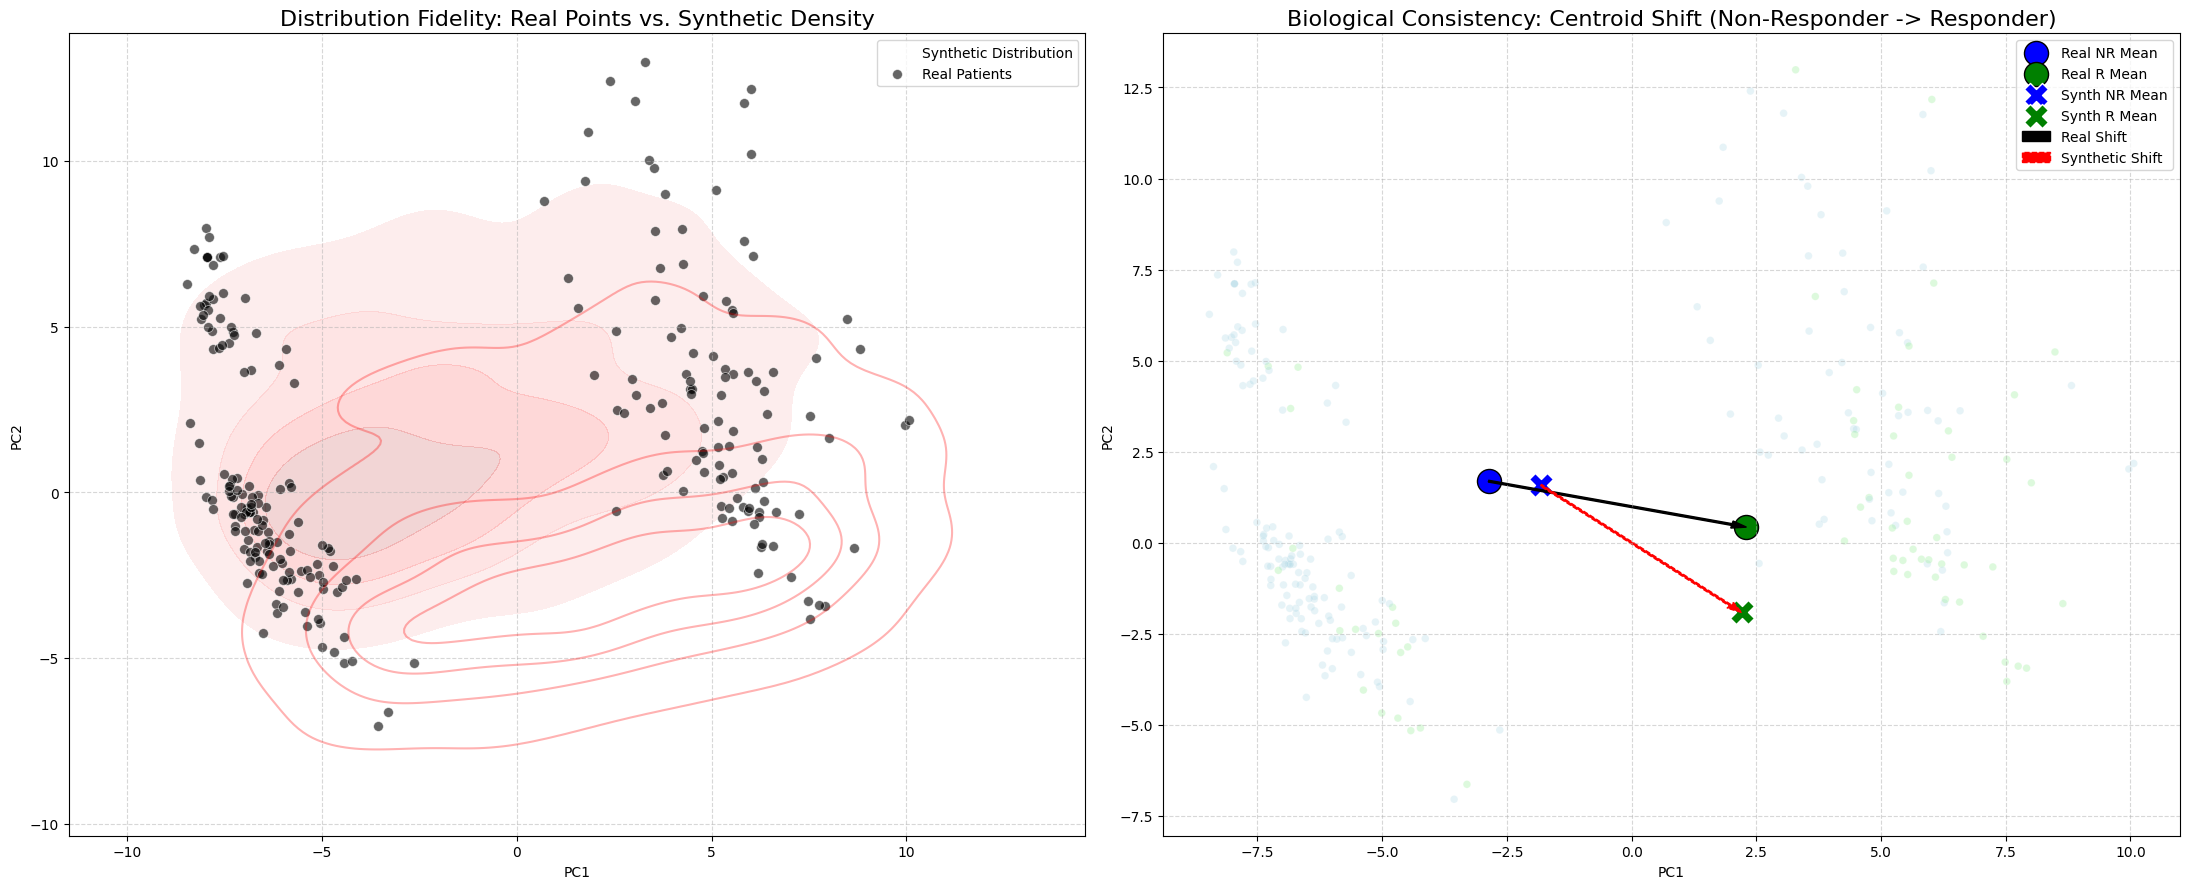

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def advanced_pca_visualization(real_latents, real_labels, synth_nr, synth_r):
    # --- 1. Prepare Data ---
    # Combine for PCA fitting
    X_combined = np.vstack([real_latents, synth_nr, synth_r])
    
    # Scale and Fit PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_combined)
    
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # Split back out
    n_real = len(real_latents)
    n_synth_nr = len(synth_nr)
    
    real_pca = X_pca[:n_real]
    synth_nr_pca = X_pca[n_real : n_real + n_synth_nr]
    synth_r_pca = X_pca[n_real + n_synth_nr :]
    
    # Create DataFrames for Seaborn
    df_real = pd.DataFrame(real_pca, columns=['PC1', 'PC2'])
    df_real['Condition'] = ['Responder' if l == 1 else 'Non-Responder' for l in real_labels]
    
    df_synth_nr = pd.DataFrame(synth_nr_pca, columns=['PC1', 'PC2'])
    df_synth_nr['Condition'] = 'Synthetic Non-Responder'
    
    df_synth_r = pd.DataFrame(synth_r_pca, columns=['PC1', 'PC2'])
    df_synth_r['Condition'] = 'Synthetic Responder'

    # --- 2. Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    
    # --- PLOT A: Density Overlap (Quality Check) ---
    # We use KDE (Contours) for synthetic to see the "Shape" without the noise of thousands of dots
    sns.kdeplot(
        x=synth_nr_pca[:, 0], y=synth_nr_pca[:, 1], 
        ax=axes[0], color='red', fill=True, alpha=0.2, levels=5, label='Synthetic Distribution'
    )
    sns.kdeplot(
        x=synth_r_pca[:, 0], y=synth_r_pca[:, 1], 
        ax=axes[0], color='red', fill=False, alpha=0.3, levels=5
    )
    
    # Plot Real Data on top
    sns.scatterplot(
        data=df_real, x='PC1', y='PC2', 
        color='black', alpha=0.6, s=50, ax=axes[0], label='Real Patients'
    )
    
    axes[0].set_title("Distribution Fidelity: Real Points vs. Synthetic Density", fontsize=16)
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # --- PLOT B: Centroid Shift (Biological Check) ---
    # This is the most important plot for your thesis
    
    # Calculate Centroids
    real_nr_center = df_real[df_real['Condition'] == 'Non-Responder'][['PC1', 'PC2']].mean()
    real_r_center = df_real[df_real['Condition'] == 'Responder'][['PC1', 'PC2']].mean()
    
    synth_nr_center = df_synth_nr[['PC1', 'PC2']].mean()
    synth_r_center = df_synth_r[['PC1', 'PC2']].mean()
    
    # Plot Real Clouds (faint)
    sns.scatterplot(
        data=df_real, x='PC1', y='PC2', hue='Condition', 
        palette={'Non-Responder': 'lightblue', 'Responder': 'lightgreen'},
        alpha=0.3, s=30, ax=axes[1], legend=False
    )
    
    # Plot Centroids (Large Dots)
    axes[1].scatter(real_nr_center[0], real_nr_center[1], s=300, c='blue', marker='o', edgecolors='black', label='Real NR Mean')
    axes[1].scatter(real_r_center[0], real_r_center[1], s=300, c='green', marker='o', edgecolors='black', label='Real R Mean')
    
    axes[1].scatter(synth_nr_center[0], synth_nr_center[1], s=300, c='blue', marker='X', edgecolors='white', label='Synth NR Mean')
    axes[1].scatter(synth_r_center[0], synth_r_center[1], s=300, c='green', marker='X', edgecolors='white', label='Synth R Mean')
    
    # Draw Arrows (The Biological Shift)
    # Arrow 1: Real Shift (NR -> R)
    axes[1].arrow(
        real_nr_center[0], real_nr_center[1],
        real_r_center[0] - real_nr_center[0], real_r_center[1] - real_nr_center[1],
        color='black', width=0.05, head_width=0.2, length_includes_head=True, label='Real Shift'
    )
    
    # Arrow 2: Synthetic Shift (NR -> R)
    axes[1].arrow(
        synth_nr_center[0], synth_nr_center[1],
        synth_r_center[0] - synth_nr_center[0], synth_r_center[1] - synth_nr_center[1],
        color='red', width=0.05, head_width=0.2, length_includes_head=True, linestyle='--', label='Synthetic Shift'
    )

    axes[1].set_title("Biological Consistency: Centroid Shift (Non-Responder -> Responder)", fontsize=16)
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
synth_nr = torch.load('synthetic_latents_NonResponder.pt', map_location='cpu').numpy()
synth_r = torch.load('synthetic_latents_Responder.pt', map_location='cpu').numpy()
real_latents = torch.load('/kaggle/working/dca_ddpm_input_latents.pt').numpy()
advanced_pca_visualization(real_latents, real_labels, synth_nr, synth_r)

In [144]:
df_responder = pd.read_csv(r"/kaggle/working/synthetic_raw_clinical_Responder.csv")
df_nonresponder = pd.read_csv(r"/kaggle/working/synthetic_raw_clinical_NonResponder.csv")
#df_real = pd.read_csv(r"/kaggle/input/dyam123/x_clinical_unscaled_ln_pc_ihc_g.csv")
#df_clinical = pd.read_csv('/kaggle/input/dyam123/clinical_features_tmb.csv')

In [90]:
df_real['label'] = df_clinical['label']
df_real['label'] = 1 - df_real['label']

In [96]:
df_real['label'].value_counts()

label
0    185
1     62
Name: count, dtype: int64

In [145]:
import pandas as pd
import numpy as np

def binarize_data_with_weighted_calibration(df_real, df_synth_responder, df_synth_nonresponder, binary_cols, ecog_cols, label_col='label'):
    """
    Biến đổi các cột continuous output từ DDPM thành 0/1 dựa trên tỷ lệ thực tế.
    
    Args:
        df_real: Dữ liệu thật (cần có cột label_col để tính tỷ lệ Responder/Non-Responder).
        df_synth_responder: Dữ liệu sinh nhóm Responder.
        df_synth_nonresponder: Dữ liệu sinh nhóm Non-Responder.
        binary_cols: Danh sách các cột nhị phân cần xử lý (Gen, Thuốc...).
        ecog_cols: Danh sách các cột ECOG (ecog_0, ecog_1...) để xử lý riêng bằng Argmax.
        label_col: Tên cột nhãn trong dữ liệu thật (VD: 'Response', 'Label').
    
    Returns:
        df_resp_final, df_nonresp_final: Hai dataframe đã được binarize (0/1).
        thresholds_log: Bảng ghi lại các ngưỡng đã dùng để kiểm tra.
    """
    
    # 1. Copy để không làm thay đổi dữ liệu gốc
    df_resp_final = df_synth_responder.copy()
    df_nonresp_final = df_synth_nonresponder.copy()
    
    # ---------------------------------------------------------
    # PHẦN 1: XỬ LÝ ECOG (ONE-HOT -> ARGMAX)
    # ---------------------------------------------------------
    print("--- Processing ECOG (Argmax) ---")
    # Logic: Trong nhóm ecog_0...ecog_3, cột nào có giá trị lớn nhất thì set là 1, còn lại là 0
    for df in [df_resp_final, df_nonresp_final]:
        # Tìm chỉ số cột lớn nhất (0, 1, 2, hoặc 3)
        max_idx = df[ecog_cols].idxmax(axis=1)
        
        # Reset toàn bộ về 0
        df[ecog_cols] = 0
        
        # Set 1 tại vị trí max
        for col in ecog_cols:
            df.loc[max_idx == col, col] = 1
            
    # ---------------------------------------------------------
    # PHẦN 2: XỬ LÝ BINARY COLS (WEIGHTED CALIBRATION)
    # ---------------------------------------------------------
    print("--- Processing Binary Features (Weighted Calibration) ---")
    
    # Tính tỷ lệ thực tế (Real World Ratios)
    n_real = len(df_real)
    # Giả sử label=1 là Responder
    n_real_resp = df_real[label_col].sum() 
    
    real_resp_ratio = n_real_resp / n_real
    real_nonresp_ratio = 1.0 - real_resp_ratio
    
    print(f"Real World Ratio -> Responder: {real_resp_ratio:.1%}, Non-Responder: {real_nonresp_ratio:.1%}")
    
    threshold_logs = []
    
    # Lọc bỏ các cột ECOG ra khỏi danh sách binary_cols nếu lỡ bị trùng
    actual_binary_cols = [c for c in binary_cols if c not in ecog_cols]

    for col in actual_binary_cols:
        # A. Tính tần suất thực tế (Real Prevalence)
        real_prev = df_real[col].mean()
        
        # Xử lý biên: Nếu thực tế không bao giờ xuất hiện (0%) hoặc luôn xuất hiện (100%)
        if real_prev <= 0.001:
            threshold_value = np.inf # Không bao giờ chọn
        elif real_prev >= 0.999:
            threshold_value = -np.inf # Luôn chọn
        else:
            # B. Tạo mẫu ảo (Virtual Sample) để tìm ngưỡng
            # Mục tiêu: Tạo một tập dữ liệu có tỷ lệ Responder/Non-Responder giống hệt thực tế
            
            n_synth_resp = len(df_synth_responder)
            n_synth_non = len(df_synth_nonresponder)
            
            # Tính toán số lượng mẫu cần lấy để đảm bảo đúng tỷ lệ real_resp_ratio
            # Chiến thuật: Giữ nguyên nhóm nhỏ hơn, downsample nhóm lớn hơn theo tỷ lệ
            if real_resp_ratio < 0.5: 
                # Thực tế Responder ít -> Lấy ít Responder từ dữ liệu sinh
                target_non = 2000 # Lấy mẫu đủ lớn
                target_resp = int(target_non * (real_resp_ratio / real_nonresp_ratio))
            else:
                target_resp = 2000
                target_non = int(target_resp * (real_nonresp_ratio / real_resp_ratio))
            
            # Lấy mẫu (có lặp lại để đảm bảo đủ số lượng)
            sample_resp = df_synth_responder[col].sample(n=target_resp, replace=True, random_state=420)
            sample_non = df_synth_nonresponder[col].sample(n=target_non, replace=True, random_state=420)
            
            virtual_population = pd.concat([sample_resp, sample_non])
            
            # C. Tìm ngưỡng (Threshold)
            quantile = 1.0 - real_prev
            threshold_value = virtual_population.quantile(quantile)
        
        # D. Áp dụng ngưỡng vào dữ liệu sinh gốc
        df_resp_final[col] = (df_synth_responder[col] > threshold_value).astype(int)
        df_nonresp_final[col] = (df_synth_nonresponder[col] > threshold_value).astype(int)
        
        # Log lại thông tin
        threshold_logs.append({
            'Feature': col,
            'Real_Prevalence': real_prev,
            'Threshold': threshold_value,
            'Synth_Resp_Mean': df_resp_final[col].mean(),
            'Synth_NonResp_Mean': df_nonresp_final[col].mean()
        })
        
    return df_resp_final, df_nonresp_final, pd.DataFrame(threshold_logs)

# --- CÁCH SỬ DỤNG ---

# 1. Định nghĩa cột
ecog_cols = ['ecog_0', 'ecog_1', 'ecog_2', 'ecog_3']
binary_cols_process = [
    'EGFR_driver', 'ERBB2_driver', 'BRAF_driver', 'MET_driver', 'STK11_driver', 
    'ARID1A_driver', 'io_drug_Atezolizumab', 'io_drug_Durvalumab', 'io_drug_Ipilimumab', 
    'io_drug_Nivolumab', 'io_drug_Pembrolizumab', 'io_drug_Resection', 'io_drug_Tremelimumab'
]

# 2. Chạy hàm (Giả sử cột nhãn trong df_real tên là 'Response')
df_synth_R_binary, df_synth_NR_binary, logs = binarize_data_with_weighted_calibration(
    df_real=df_real,
    df_synth_responder=df_responder,
    df_synth_nonresponder=df_nonresponder,
    binary_cols=binary_cols_process,
    ecog_cols=ecog_cols,
    label_col='label' # Thay bằng tên cột nhãn thật của bạn
)

# 3. Kiểm tra kết quả
print(logs.head())
print(df_synth_R_binary[['EGFR_driver', 'ecog_0', 'ecog_1']].head())

--- Processing ECOG (Argmax) ---
--- Processing Binary Features (Weighted Calibration) ---
Real World Ratio -> Responder: 25.1%, Non-Responder: 74.9%
        Feature  Real_Prevalence  Threshold  Synth_Resp_Mean  \
0   EGFR_driver         0.089069  -1.907351            0.012   
1  ERBB2_driver         0.076923  -2.341199            0.086   
2   BRAF_driver         0.028340  -3.059377            0.028   
3    MET_driver         0.048583  -2.546958            0.072   
4  STK11_driver         0.178138  -1.143353            0.041   

   Synth_NonResp_Mean  
0               0.115  
1               0.067  
2               0.024  
3               0.038  
4               0.232  
   EGFR_driver  ecog_0  ecog_1
0            0       0       1
1            0       1       0
2            0       1       0
3            1       0       0
4            0       0       1


In [152]:
df_synth_NR_binary['ERBB2_driver'].value_counts()

ERBB2_driver
0    933
1     67
Name: count, dtype: int64

In [153]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

def compare_binary_groups(df_resp, df_nonresp, features):
    """
    So sánh tỷ lệ xuất hiện của các đặc trưng nhị phân giữa 2 nhóm.
    Trả về DataFrame có kèm P-value và Enrichment Ratio.
    """
    results = []
    
    n_resp = len(df_resp)
    n_nonresp = len(df_nonresp)
    
    for col in features:
        # 1. Tính số lượng và tỷ lệ
        count_r = df_resp[col].sum()
        count_nr = df_nonresp[col].sum()
        
        freq_r = count_r / n_resp
        freq_nr = count_nr / n_nonresp
        
        # 2. Tính Enrichment Ratio (Responder / Non-Responder)
        # Thêm 1e-6 để tránh chia cho 0
        ratio = freq_r / (freq_nr + 1e-6)
        
        # 3. Tính độ chênh lệch (Difference)
        diff = freq_r - freq_nr
        
        # 4. Kiểm định thống kê (Chi-square test)
        # Bảng ngẫu nhiên: [[Resp_Pos, Resp_Neg], [NonResp_Pos, NonResp_Neg]]
        contingency_table = [
            [count_r, n_resp - count_r],
            [count_nr, n_nonresp - count_nr]
        ]
        
        # Dùng Chi2 cho mẫu lớn, Fisher cho mẫu nhỏ (dưới 5 quan sát)
        if count_r < 5 or count_nr < 5:
            odds_ratio, p_value = stats.fisher_exact(contingency_table)
        else:
            chi2, p_value, dof, ex = stats.chi2_contingency(contingency_table)
            
        results.append({
            'Feature': col,
            'Responder_Freq': freq_r,
            'NonResponder_Freq': freq_nr,
            'Difference (R - NR)': diff,
            'Ratio (R / NR)': ratio,
            'P_value': p_value
        })
        
    res_df = pd.DataFrame(results)
    
    # Sắp xếp theo mức độ chênh lệch (Ratio)
    return res_df.sort_values(by='Ratio (R / NR)', ascending=False)

# --- CHUẨN BỊ LIST CỘT ---
# Gộp list binary và ecog lại
ALL_BINARY_FEATURES = [
    'EGFR_driver', 'ERBB2_driver', 'BRAF_driver', 'MET_driver', 'STK11_driver', 'ARID1A_driver',
    'io_drug_Atezolizumab', 'io_drug_Durvalumab', 'io_drug_Ipilimumab', 'io_drug_Nivolumab', 
    'io_drug_Pembrolizumab', 'io_drug_Resection', 'io_drug_Tremelimumab',
    'ecog_0', 'ecog_1', 'ecog_2', 'ecog_3'
]

# --- CHẠY HÀM ---
comparison_df = compare_binary_groups(df_synth_R_binary, df_synth_NR_binary, ALL_BINARY_FEATURES)

# Hiển thị bảng màu mè cho dễ nhìn
# def highlight_significance(s):
#     is_significant = s['P_value'] < 0.05
#     is_enriched = s['Ratio (R / NR)'] > 1.5
#     is_depleted = s['Ratio (R / NR)'] < 0.66
    
#     color = ''
#     if is_significant:
#         if is_enriched: color = 'background-color: #d4edda' # Xanh lá (Tốt cho Responder)
#         elif is_depleted: color = 'background-color: #f8d7da' # Đỏ (Xấu/Kháng thuốc)
#     return [color] * len(s)

# Hiển thị 10 dòng đầu
print("Bảng so sánh thống kê:")
display(comparison_df)

Bảng so sánh thống kê:


,Feature,Responder_Freq,NonResponder_Freq,Difference (R - NR),Ratio (R / NR),P_value
12,io_drug_Tremelimumab,0.017,0.003,0.014,5.664778,2.458343e-03
5,ARID1A_driver,0.143,0.035,0.108,4.085598,4.366355e-17
13,ecog_0,0.134,0.034,0.100,3.941061,1.456828e-15
7,io_drug_Durvalumab,0.043,0.017,0.026,2.529263,1.049106e-03
10,io_drug_Pembrolizumab,0.575,0.292,0.283,1.969171,4.324150e-37
3,MET_driver,0.072,0.038,0.034,1.894687,1.209228e-03
1,ERBB2_driver,0.086,0.067,0.019,1.283563,1.299529e-01
2,BRAF_driver,0.028,0.024,0.004,1.166618,6.733599e-01
14,ecog_1,0.834,0.898,-0.064,0.928729,3.543856e-05
9,io_drug_Nivolumab,0.302,0.472,-0.170,0.639829,8.584028e-15


In [8]:
import torch
import pandas as pd
import numpy as np

# 1. Load your aligned clinical dataframe (Raw Data)
df_clinical = pd.read_csv("/kaggle/input/dyam123/clinical_features_tmb.csv")
df_clinical = df_clinical[df_clinical['TMB'].notna()].copy()

# 2. Define the Mapping Logic
def get_egfr_condition(row):
    # Assumption: In your raw CSV, 0 = Responder, 1 = Non-Responder
    is_responder = row['label'] == 0 
    has_egfr = row['STK11_driver'] == 1
    
    if is_responder:
        return 2 # Class 2: Responder (Control Group 1)
    else:
        # It is a Non-Responder
        if has_egfr:
            return 0 # Class 0: EGFR+ Non-Responder (Target Group)
        else:
            return 1 # Class 1: EGFR- Non-Responder (Control Group 2)

# 3. Apply Mapping
# This creates a list of [0, 1, 2]
new_labels_list = df_clinical.apply(get_egfr_condition, axis=1).values
new_labels_tensor = torch.tensor(new_labels_list, dtype=torch.long)

# 4. Check Counts
# EGFR is rarer than STK11. Check if Class 0 has enough samples (at least > 5-10)
print("New Label Counts for EGFR Analysis:")
count_0 = (new_labels_tensor == 0).sum().item()
count_1 = (new_labels_tensor == 1).sum().item()
count_2 = (new_labels_tensor == 2).sum().item()

print(f"  Label 0 (EGFR+ Non-Responder): {count_0}")
print(f"  Label 1 (EGFR- Non-Responder): {count_1}")
print(f"  Label 2 (Responder):            {count_2}")

if count_0 < 10:
    print("⚠️ WARNING: The EGFR+ Non-Responder group is very small. The DDPM may struggle to learn this class distinctly.")

# 5. Save
output_path = 'dca_ddpm_input_labels_egfr.pt'
torch.save(new_labels_tensor, output_path)
print(f"Saved new labels to '{output_path}'")

KeyError: 'STK_driver'

In [28]:
import torch
import pandas as pd
import numpy as np

# 1. Load your aligned clinical dataframe (Raw Data)
# This dataframe MUST be in the same order as your graph nodes/latents
df_clinical = pd.read_csv("/kaggle/input/dyam123/clinical_features_tmb.csv")
df_clinical = df_clinical[df_clinical['TMB'].notna()].copy()

# Ensure indices align with the saved latents!
# (Assuming df_clinical was already aligned in your previous steps)

# 2. Define the Mapping Logic
def get_stk11_condition(row):
    # Adjust these column names/values based on your exact CSV format
    is_responder = row['label'] == 0  # Assuming 0 = Responder in raw CSV
    has_stk11 = row['STK11_driver'] == 1
    
    if is_responder:
        return 2 # Class 2: Responder (Any)
    else:
        # It is a Non-Responder
        if has_stk11:
            return 0 # Class 0: STK11+ Non-Responder
        else:
            return 1 # Class 1: STK11- Non-Responder

# 3. Apply Mapping
# This creates a list of [0, 1, 2]
new_labels_list = df_clinical.apply(get_stk11_condition, axis=1).values
new_labels_tensor = torch.tensor(new_labels_list, dtype=torch.long)

# 4. Check Counts (CRITICAL: Ensure groups aren't too small)
print("New Label Counts:")
print(f"  Label 0 (STK11+ Non-Responder): {(new_labels_tensor == 0).sum().item()}")
print(f"  Label 1 (STK11- Non-Responder): {(new_labels_tensor == 1).sum().item()}")
print(f"  Label 2 (Responder):            {(new_labels_tensor == 2).sum().item()}")

# 5. Save
torch.save(new_labels_tensor, 'dca_ddpm_input_labels_stk11.pt')
print("Saved new labels to 'dca_ddpm_input_labels_stk11.pt'")

New Label Counts:
  Label 0 (STK11+ Non-Responder): 39
  Label 1 (STK11- Non-Responder): 146
  Label 2 (Responder):            62
Saved new labels to 'dca_ddpm_input_labels_stk11.pt'


In [29]:
import torch
import torch.nn as nn
from itertools import combinations
from typing import Optional, List, Tuple

# --- 1. Positional Embedding (Standard) ---
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# --- 2. The DCA Block (Robust for 1D vectors) ---
class DCA_Block(nn.Module):
    """
    Dual-Cross-Attention Block for pairwise interaction.
    Handles input shapes of (Batch, Dim) by temporarily treating them as sequence length 1.
    """
    def __init__(self, d_embed: int, n_heads: int, num_modalities: int):
        super().__init__()
        self.num_modalities = num_modalities
        
        # Create a cross-attention layer for every possible pair
        # Formula: n * (n-1) interactions
        self.cross_attentions = nn.ModuleList([
            nn.MultiheadAttention(d_embed, n_heads, batch_first=True)
            for _ in range(num_modalities * (num_modalities - 1))
        ])
        
        self.norms = nn.ModuleList([nn.LayerNorm(d_embed) for _ in range(num_modalities)])
        
        # Feed Forward Networks per modality
        self.ffns = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_embed, d_embed * 4), # MLP expansion factor usually 2 or 4
                nn.GELU(),
                nn.Dropout(0.5),
                nn.Linear(d_embed * 4, d_embed),
                nn.Dropout(0.5)
            ) for _ in range(num_modalities)
        ])
        self.ffn_norms = nn.ModuleList([nn.LayerNorm(d_embed) for _ in range(num_modalities)])

    def forward(self, streams: List[torch.Tensor]) -> List[torch.Tensor]:
        # Input streams: List of [Batch, Dim]
        
        # 1. Unsqueeze to [Batch, 1, Dim] for MultiheadAttention
        seq_streams = [s.unsqueeze(1) for s in streams]
        updated_streams = [s.clone() for s in seq_streams]
        
        attn_idx = 0
        
        # 2. Perform all-pairs cross-attention
        for i, j in combinations(range(self.num_modalities), 2):
            # i attends to j (Query=i, Key=j, Val=j)
            attn_out_i, _ = self.cross_attentions[attn_idx](
                query=seq_streams[i], key=seq_streams[j], value=seq_streams[j]
            )
            updated_streams[i] = updated_streams[i] + attn_out_i
            attn_idx += 1

            # j attends to i (Query=j, Key=i, Val=i)
            attn_out_j, _ = self.cross_attentions[attn_idx](
                query=seq_streams[j], key=seq_streams[i], value=seq_streams[i]
            )
            updated_streams[j] = updated_streams[j] + attn_out_j
            attn_idx += 1
            
        # 3. Squeeze back to [Batch, Dim] and apply FFN + Residuals
        final_streams = []
        for i in range(self.num_modalities):
            # Squeeze
            x = updated_streams[i].squeeze(1) 
            
            # Add & Norm (Attention Residual)
            x = self.norms[i](x + streams[i]) 
            
            # FFN + Add & Norm (FFN Residual)
            x = self.ffn_norms[i](x + self.ffns[i](x))
            
            final_streams.append(x)
            
        return final_streams

# --- 3. Multimodal Linear Block ---
class MultimodalLinearBlock(nn.Module):
    """
    Replaces the ResNet block. Uses simple Linear layers + SiLU.
    Injects Time/Condition embeddings into each modality stream BEFORE the DCA.
    """
    def __init__(self, hidden_dim: int, time_emb_dim: int, 
                 num_modalities: int, n_heads: int):
        super().__init__()
        self.num_modalities = num_modalities
        
        # Ensure hidden_dim is divisible by num_modalities
        assert hidden_dim % num_modalities == 0, "Hidden dim must be divisible by num_modalities"
        self.d_embed_per_mod = hidden_dim // num_modalities

        # Time/Condition Injection Layers (Scale and Shift is SOTA for Diffusion)
        # Here we do simple addition for parameter efficiency
        self.time_mlps = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(), 
                nn.Linear(time_emb_dim, self.d_embed_per_mod)
            ) for _ in range(num_modalities)
        ])

        # The DCA Block
        self.dca = DCA_Block(self.d_embed_per_mod, n_heads, num_modalities)
        
        # Simple residual projection for the whole block
        self.residual_layer = nn.Identity() # Since input/output dims are same

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        # x: [Batch, hidden_dim] (Concatenated modalities)
        
        # 1. Split into streams
        streams = list(torch.chunk(x, self.num_modalities, dim=1))
        
        # 2. Add Time/Condition Embedding to each stream
        conditioned_streams = []
        for i, stream in enumerate(streams):
            # Time emb projection
            time_proj = self.time_mlps[i](t_emb)
            # Simple additive conditioning
            conditioned_streams.append(stream + time_proj)
            
        # 3. Interaction via DCA
        interacted_streams = self.dca(conditioned_streams)
        
        # 4. Concatenate back
        out = torch.cat(interacted_streams, dim=1)
        
        # 5. Global Residual connection
        return out + x

class DenoiseDCAMLP(nn.Module):
    """
    MLP-based Denoising Network with Dual-Cross-Attention (DCA).
    Designed for small, multi-modal tabular datasets to prevent overfitting.
    """
    def __init__(self, 
                 latent_dim_per_modality: int,
                 num_modalities: int,
                 num_classes: Optional[int] = None,
                 hidden_dim_multiplier: int = 4,
                 num_layers: int = 4,
                 n_heads: int = 4):
        """
        Args:
            latent_dim_per_modality: Dimension of ONE view's latent vector (e.g. 32).
            num_modalities: Number of views (e.g. 3).
            num_classes: For conditional generation.
            hidden_dim_multiplier: Expands input dim for the hidden layers (e.g. 4x).
            num_layers: Number of DCA Blocks.
            n_heads: Number of attention heads in DCA.
        """
        super().__init__()
        
        self.num_modalities = num_modalities
        input_dim = latent_dim_per_modality * num_modalities
        
        # Calculate hidden dimension
        # Must be divisible by num_modalities for splitting
        raw_hidden_dim = input_dim * hidden_dim_multiplier
        # Adjust to be perfectly divisible
        self.hidden_dim = (raw_hidden_dim // num_modalities) * num_modalities
        
        # --- 1. Time & Class Embeddings ---
        time_dim = self.hidden_dim // 2
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(input_dim),
            nn.Linear(input_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.is_conditional = num_classes is not None
        if self.is_conditional:
            self.class_emb = nn.Embedding(num_classes, time_dim)
            self.cond_drop_prob = 0.1

        # --- 2. Input Projection ---
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim),
            nn.SiLU()
        )

        # --- 3. Stack of DCA-MLP Blocks ---
        self.layers = nn.ModuleList([
            MultimodalLinearBlock(
                hidden_dim=self.hidden_dim,
                time_emb_dim=time_dim,
                num_modalities=num_modalities,
                n_heads=n_heads
            )
            for _ in range(num_layers)
        ])

        # --- 4. Final Output Projection ---
        self.output_proj = nn.Sequential(
            nn.LayerNorm(self.hidden_dim),
            nn.SiLU(),
            nn.Linear(self.hidden_dim, input_dim)
        )

    def forward(self, x: torch.Tensor, time: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        x: [Batch, Total_Latent_Dim]
        time: [Batch]
        y: [Batch] (Labels)
        """
        # 1. Embeddings
        t_emb = self.time_mlp(time)
        
        if self.is_conditional:
            if self.training:
                # Classifier-free guidance dropout
                mask = torch.rand(y.shape[0], device=y.device) < self.cond_drop_prob
                y = y.clone()
                y[mask] = 0 
            c_emb = self.class_emb(y)
            # Add class embedding to time embedding
            t_emb = t_emb + c_emb

        # 2. Project Input
        x = self.input_proj(x)

        # 3. Pass through DCA Blocks
        for layer in self.layers:
            x = layer(x, t_emb)

        # 4. Project to Output (Predict Noise)
        return self.output_proj(x)

In [30]:
#from models.ddpm import DenoiseDCAMLP, ConditionalDDPM

LATENT_DIM_PER_MODALITY = model_config['d_embed']
NUM_MODALITIES= 3

# --- Update Config ---
stk11_ddpm_config = ddpm_config.copy()
stk11_ddpm_config['num_classes'] = 4  # (Uncond + STK11_NR + Other_NR + Resp)

denoising_network = DenoiseDCAMLP(
    latent_dim_per_modality=LATENT_DIM_PER_MODALITY,
    num_modalities=NUM_MODALITIES,
    num_classes=4,
    hidden_dim_multiplier=5, # Expand 32*3=96 -> ~384 hidden size
    num_layers=4,            # 4 Layers of DCA interaction is deep enough for N=247
    n_heads=8               # 4 heads for attention
).to(device)

ddpm_model = ConditionalDDPM(
    denoise_fn=denoising_network,
    latent_dim=LATENT_DIM_PER_MODALITY * NUM_MODALITIES,
    timesteps=stk11_ddpm_config['timesteps']
).to(device)

# --- Load Data ---
# Use existing latents, but NEW labels
latents = torch.load('dca_ddpm_input_latents.pt')
labels_stk11 = torch.load('dca_ddpm_input_labels_stk11.pt')

# --- Train ---
print("Training STK11-Specific DDPM...")
trained_model_stk11, scaler_stk11 = train_single_conditional_ddpm(
    ddpm_model=ddpm_model,
    latents=latents,
    labels=labels_stk11, 
    ddpm_config=stk11_ddpm_config,
    device=device
)
if trained_model_stk11:
    print("  -> DDPM training complete!")
    # Save the trained DDPM and the scaler for the analysis phase
    torch.save(trained_model_stk11.state_dict(), 'ddpm_responder_stk11.pth')
    import pickle
    with open('ddpm_responder_scaler_stk11.pkl', 'wb') as f:
        pickle.dump(scaler_stk11, f)
    print("  -> DDPM model and scaler saved.")

Training STK11-Specific DDPM...


Training DDPM:  35%|███▌      | 1765/5000 [04:58<09:06,  5.92it/s, t_loss=0.1060, v_loss=0.1131]



Early stopping at epoch 1766.
  -> DDPM training complete!
  -> DDPM model and scaler saved.


In [32]:
import torch
import pickle
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import RobustScaler
from models.gvae_model import GVAE

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Paths ---
# Ensure these point to the STK11-trained model
DDPM_MODEL_PATH = '/kaggle/working/ddpm_responder_stk11.pth' 
DDPM_SCALER_PATH = '/kaggle/working/ddpm_responder_scaler_stk11.pkl'
GVAE_MODEL_PATH = '/kaggle/working/best_model_fold_1.pth'
CLINICAL_SCALER_PATH = '/kaggle/input/dyam123/clinical_scaler.pkl'

# --- Generation Parameters ---
NUM_SAMPLES_TO_GENERATE = 2000
GUIDANCE_SCALE = 3.5 # High guidance to find the "Archetype" of STK11 resistance

# --- Feature Definitions ---
NUMERICAL_COLS = ['albumin', 'dnlr', 'TMB', 'tumor_burden', 'clinical_pdl1_score']
BINARY_COLS = [
    'EGFR_driver', 'ERBB2_driver', 'BRAF_driver', 'MET_driver', 
    'STK11_driver', 'ARID1A_driver', 'io_drug_Atezolizumab', 'io_drug_Durvalumab',
    'io_drug_Ipilimumab', 'io_drug_Nivolumab', 'io_drug_Pembrolizumab', 
    'io_drug_Resection', 'io_drug_Tremelimumab','ecog_0', 'ecog_1', 'ecog_2', 'ecog_3'
]
ALL_CLINICAL_COLS = NUMERICAL_COLS + BINARY_COLS

# Columns that were log-transformed (check your preprocessing!)
COLS_TO_EXP = ['albumin', 'dnlr', 'TMB', 'tumor_burden', 'clinical_pdl1_score'] 

# --- 1. Initialize Models ---
# GVAE
gvae_master_model = GVAE(**model_config).to(DEVICE)
gvae_master_model.load_state_dict(torch.load(GVAE_MODEL_PATH, map_location=DEVICE))
gvae_master_model.eval()

# DDPM (STK11 Configuration)
LATENT_DIM_PER_MODALITY = model_config['d_embed']
NUM_MODALITIES = 3
NUM_CLASSES_STK11 = 4 # Uncond + STK11_NR + Other_NR + Resp

denoising_network = DenoiseDCAMLP(
    latent_dim_per_modality=LATENT_DIM_PER_MODALITY,
    num_modalities=NUM_MODALITIES,
    num_classes=4,
    hidden_dim_multiplier=5, 
    num_layers=4,            
    n_heads=8
).to(DEVICE)

ddpm_model = ConditionalDDPM(
    denoise_fn=denoising_network,
    latent_dim=LATENT_DIM_PER_MODALITY * NUM_MODALITIES,
    timesteps=1000 
).to(DEVICE)

ddpm_model.load_state_dict(torch.load(DDPM_MODEL_PATH))
ddpm_model.eval()

# Load Scalers
with open(DDPM_SCALER_PATH, 'rb') as f:
    ddpm_latent_scaler = pickle.load(f)
with open(CLINICAL_SCALER_PATH, 'rb') as f:
    scaler_data = pickle.load(f)
clinical_feature_scaler = scaler_data['scaler']

# ==============================================================================
# --- 2. GENERATION LOOP ---
# ==============================================================================

# Mapping based on your training logic:
# Label 0 (Input) -> 1 (Internal): STK11+ Non-Responder
# Label 1 (Input) -> 2 (Internal): STK11- Non-Responder
CONDITIONS_TO_GENERATE = {
    "STK11_Pos_NR": 1, 
    "STK11_Neg_NR": 2     
}

for condition_name, condition_label in CONDITIONS_TO_GENERATE.items():
    print(f"\n=== Generating: {condition_name} (Label {condition_label}) ===")

    # A. DDPM Sampling
    y_condition = torch.full((NUM_SAMPLES_TO_GENERATE,), fill_value=condition_label, dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        latents_scaled = ddpm_model.sample(y=y_condition, guidance_scale=GUIDANCE_SCALE)
    
    # B. Rescaling & Splitting
    latents_gvae_space = ddpm_latent_scaler.inverse_transform(latents_scaled.cpu().numpy())
    latents_tensor = torch.from_numpy(latents_gvae_space).float().to(DEVICE)
    clinical_latent_stream = torch.chunk(latents_tensor, NUM_MODALITIES, dim=1)[0]
    
    # C. GVAE Decoding
    with torch.no_grad():
        recon_logits = gvae_master_model.attribute_decoders['clinical'](clinical_latent_stream)
    
    # D. Post-Processing (Safe Decoding)
    df_gen = pd.DataFrame(recon_logits.cpu().numpy(), columns=ALL_CLINICAL_COLS)
    
    # 1. Inverse Scaling
    df_gen[NUMERICAL_COLS] = clinical_feature_scaler.inverse_transform(df_gen[NUMERICAL_COLS])
    
    # 2. Safe Exponentiation
    for col in COLS_TO_EXP:
        # Clip to prevent explosion (log value > 6 is ~400 raw)
        df_gen[col] = df_gen[col].clip(upper=6.0)
        df_gen[col] = np.expm1(df_gen[col])
        
    # 3. Biological Clamping (Optional sanity)
    df_gen['clinical_pdl1_score'] = df_gen['clinical_pdl1_score'].clip(upper=100)
    df_gen['TMB'] = df_gen['TMB'].clip(lower=0, upper=200)

    # 4. Binary Thresholding (Calibrated or Simple)
    # Using simple sigmoid here for raw output, can use calibration if needed
    df_gen[BINARY_COLS] = (torch.sigmoid(torch.tensor(df_gen[BINARY_COLS].values)) > 0).int().numpy()

    # Save
    fname = f'synthetic_stk11_{condition_name}.csv'
    df_gen.to_csv(fname, index=False)
    print(f"  -> Saved to {fname}")
    
    # Quick check
    stk11_rate = df_gen['STK11_driver'].mean()
    print(f"  -> Generated egfr Prevalence: {stk11_rate:.2%}")


=== Generating: STK11_Pos_NR (Label 1) ===


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.7.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

  -> Saved to synthetic_stk11_STK11_Pos_NR.csv
  -> Generated egfr Prevalence: 100.00%

=== Generating: STK11_Neg_NR (Label 2) ===


DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

  -> Saved to synthetic_stk11_STK11_Neg_NR.csv
  -> Generated egfr Prevalence: 100.00%


In [162]:
df_egfr_neg = pd.read_csv('/kaggle/working/synthetic_egfr_EGFR_Neg_NR.csv')
df_egfr_pos = pd.read_csv('/kaggle/working/synthetic_egfr_EGFR_Pos_NR.csv')

In [164]:
df_egfr_pos['EGFR_driver'].value_counts()

EGFR_driver
0    2000
Name: count, dtype: int64